# SUPPORT2 Mini Project
**Dataset:** SUPPORT2 — Study to Understand Prognoses, Preferences, Outcomes and Risks of Treatment  
**Research Question:** Can we predict whether a critically ill patient will die (within hospital or within 6 months) using a small set of clinical and demographic features?  
**Target Variable:** `death` (0 = survived, 1 = died)  
**Scope:** Mini/exploratory version. One cleaning pass, two EDA visuals, one model (Logistic Regression).

## 0. Setup — Imports & Config

In [1]:
# Standard data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Make plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All imports successful.")

All imports successful.


---
## 1. Introduction — Load & First Look

**Goal:** Understand the raw shape of the data before touching anything.

Key questions to answer as you run these cells:
- How many rows and columns?
- What does each column represent? (Refer to the SUPPORT2 data dictionary if needed)
- What is the class balance of our target `death`?

In [2]:
# Load the dataset — assumes CSV is in the same folder as this notebook
df = pd.read_csv("support2_raw_complete.csv")

print("Shape:", df.shape)
df.head()

Shape: (9105, 48)


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
2,3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
3,4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
4,5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [3]:
# Column data types — important for knowing what needs encoding later
df.dtypes

id            int64
age         float64
death         int64
sex             str
hospdead      int64
slos          int64
d.time        int64
dzgroup         str
dzclass         str
num.co        int64
edu         float64
income          str
scoma       float64
charges     float64
totcst      float64
totmcst     float64
avtisst     float64
race            str
sps         float64
aps         float64
surv2m      float64
surv6m      float64
hday          int64
diabetes      int64
dementia      int64
ca              str
prg2m       float64
prg6m       float64
dnr             str
dnrday      float64
meanbp      float64
wblc        float64
hrt         float64
resp        float64
temp        float64
pafi        float64
alb         float64
bili        float64
crea        float64
sod         float64
ph          float64
glucose     float64
bun         float64
urine       float64
adlp        float64
adls        float64
sfdm2           str
adlsc       float64
dtype: object

In [4]:
# Class balance of the target variable
# Ask yourself: is this balanced? What does imbalance mean for a model?
print(df["death"].value_counts())
print("\nDeath rate:", df["death"].mean().round(3))

death
1    6201
0    2904
Name: count, dtype: int64

Death rate: 0.681


In [5]:
# Missing value audit — sorted worst to best
# We'll use this to decide which columns to keep vs. drop
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})[missing > 0]

,missing_count,missing_%
adlp,5641,62.0
urine,4862,53.4
glucose,4500,49.4
bun,4352,47.8
totmcst,3475,38.2
alb,3372,37.0
income,2982,32.8
adls,2867,31.5
bili,2601,28.6
pafi,2325,25.5


**📝 Pause here.** Before running the next section, write down (in a markdown cell or notes):
1. Which columns have >40% missing and should probably be dropped?
2. Which columns look most useful for predicting death?

---
## 2. Data Cleaning & Preparation

**Strategy for this mini version:**
- Drop columns with >40% missing (too sparse to impute reliably)
- Select a small, interpretable feature set
- Drop rows with remaining missing values (simple; revisit with imputation in full project)
- Encode categorical variables

In [6]:
# Step 1: Drop columns missing more than 40% of values
threshold = 0.4
cols_to_drop = missing_pct[missing_pct > threshold * 100].index.tolist()
print(f"Dropping {len(cols_to_drop)} high-missingness columns:")
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)
print(f"\nShape after drop: {df_clean.shape}")

Dropping 4 high-missingness columns:
['adlp', 'urine', 'glucose', 'bun']

Shape after drop: (9105, 44)


In [7]:
# Step 2: Select a focused feature set for the mini project
# These were chosen because they are: clinically meaningful, low-missing, and a mix of
# demographic (age, sex), severity (aps, sps), and disease context (dzgroup)

FEATURES = [
    "age",
    "sex",
    "dzgroup",
    "num.co",
    "aps",
    "sps",
    "meanbp",
    "hrt",
    "resp",
    "temp",
]
TARGET = "death"

df_model = df_clean[FEATURES + [TARGET]].copy()
print("Selected feature shape:", df_model.shape)
df_model.head()

Selected feature shape: (9105, 11)


,age,sex,dzgroup,num.co,aps,sps,meanbp,hrt,resp,temp,death
0,62.84998,male,Lung Cancer,0,20.0,33.898438,97.0,69.0,22.0,36.00000,0
1,60.33899,female,Cirrhosis,2,74.0,52.695312,43.0,112.0,34.0,34.59375,1
2,52.74698,female,Cirrhosis,2,45.0,20.500000,70.0,88.0,28.0,37.39844,1
3,42.38498,female,Lung Cancer,2,19.0,20.097656,75.0,88.0,32.0,35.00000,1
4,79.88495,female,ARF/MOSF w/Sepsis,1,30.0,23.500000,59.0,112.0,20.0,37.89844,0


In [8]:
# Step 3: Drop rows with any remaining missing values
# Note: This is a simplification. For the full project, consider median/mode imputation.
before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)
print(
    f"Rows dropped due to remaining nulls: {before - after} ({((before-after)/before*100):.1f}%)"
)
print(f"Working dataset size: {df_model.shape}")

Rows dropped due to remaining nulls: 2 (0.0%)
Working dataset size: (9103, 11)


In [9]:
# Step 4: Encode categorical columns
# Logistic Regression needs numbers — 'sex' and 'dzgroup' are strings

# Binary encode sex (male=1, female=0)
df_model["sex"] = df_model["sex"].map({"male": 1, "female": 0})

# One-hot encode disease group (creates a column per category, drops one to avoid multicollinearity)
df_model = pd.get_dummies(df_model, columns=["dzgroup"], drop_first=True)

print("Shape after encoding:", df_model.shape)
print("New columns:", [c for c in df_model.columns if "dzgroup" in c])

Shape after encoding: (9103, 17)
New columns: ['dzgroup_CHF', 'dzgroup_COPD', 'dzgroup_Cirrhosis', 'dzgroup_Colon Cancer', 'dzgroup_Coma', 'dzgroup_Lung Cancer', 'dzgroup_MOSF w/Malig']


In [10]:
# Final cleaned dataset summary
df_model.describe()

,age,sex,num.co,aps,sps,meanbp,hrt,resp,temp,death
count,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000,9103.000000
mean,62.651620,0.562891,1.868615,37.595518,25.525227,84.549654,97.155300,23.330111,37.103473,0.680984
std,15.595244,0.496056,1.344555,19.903560,9.899730,27.687481,31.560738,9.574311,1.251801,0.466121
min,18.041990,0.000000,0.000000,0.000000,0.199982,0.000000,0.000000,0.000000,31.699220,0.000000
25%,52.793995,0.000000,1.000000,23.000000,19.000000,63.000000,72.000000,18.000000,36.195310,0.000000
50%,64.859990,1.000000,2.000000,34.000000,23.898438,77.000000,100.000000,24.000000,36.695310,1.000000
75%,74.001465,1.000000,3.000000,49.000000,30.199219,107.000000,120.000000,28.000000,38.195310,1.000000
max,101.847960,1.000000,9.000000,143.000000,99.187500,195.000000,300.000000,90.000000,41.695310,1.000000


---
## 3. Exploratory Data Analysis (EDA)

**Goal:** Build intuition about the data *before* modeling. What patterns exist? Which features look predictive?

We'll produce two visuals:
1. Death rate by disease group
2. Age distribution by outcome (survived vs. died)

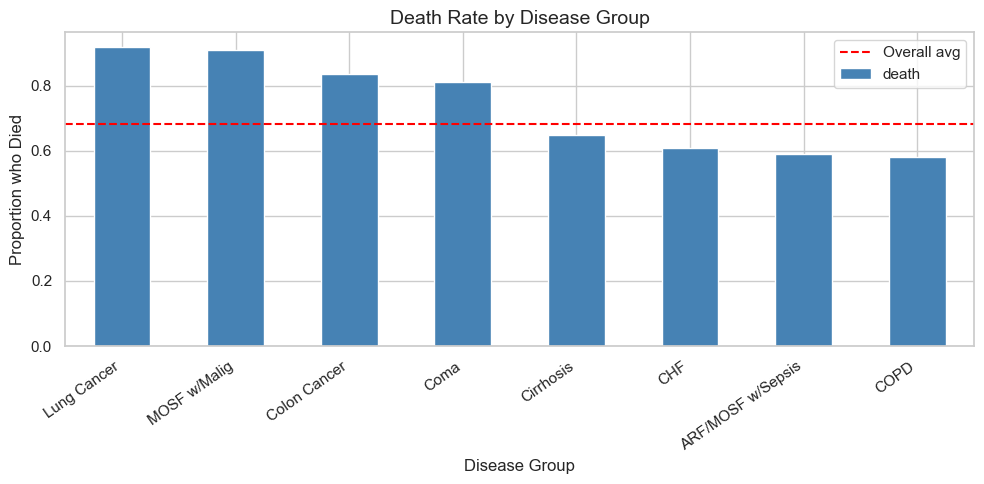

In [11]:
# EDA Visual 1: Death rate by disease group
# We use the pre-encoding df_model parent (df_clean) so dzgroup is still readable
# Re-merge dzgroup for plotting purposes only
plot_df = df_clean[["dzgroup", "death"]].dropna()

death_by_dz = plot_df.groupby("dzgroup")["death"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
death_by_dz.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Death Rate by Disease Group", fontsize=14)
ax.set_xlabel("Disease Group")
ax.set_ylabel("Proportion who Died")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.axhline(df_clean["death"].mean(), color="red", linestyle="--", label="Overall avg")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_death_rate_by_disease_group.png", dpi=150, bbox_inches="tight")
plt.show()

# What disease groups have the highest and lowest mortality? Does this make clinical sense?

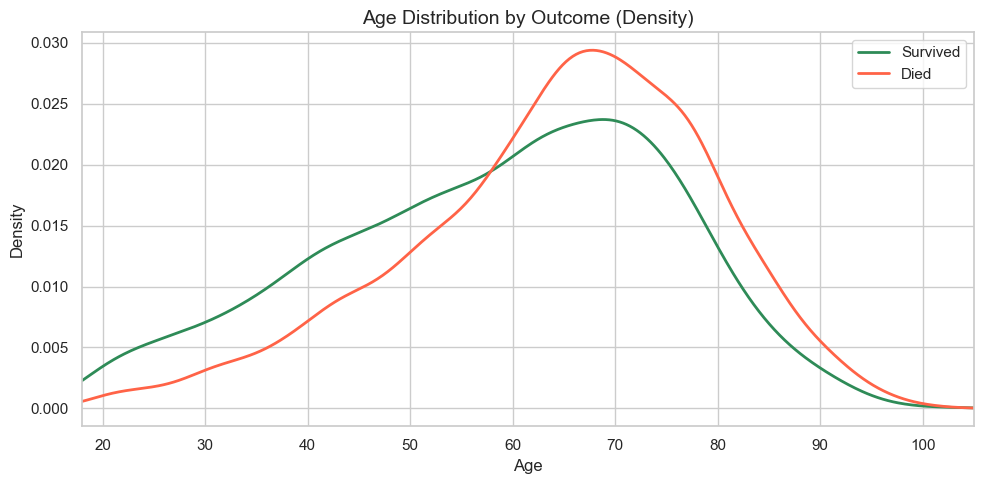

In [12]:
# EDA Visual 2: Age distribution by outcome — KDE (density) plot
# KDE normalizes each group to its own proportion, solving two problems:
# 1. The class imbalance no longer visually swamps the minority group
# 2. No misleading third color from overlapping transparent bars

fig, ax = plt.subplots()
for outcome, label, color in [(0, "Survived", "seagreen"), (1, "Died", "tomato")]:
    subset = df_clean[df_clean["death"] == outcome]["age"].dropna()
    subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)

ax.set_title("Age Distribution by Outcome (Density)", fontsize=14)
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.set_xlim(18, 105)
ax.legend()
plt.tight_layout()
plt.savefig("fig2_age_distribution_density.png", dpi=150, bbox_inches="tight")
plt.show()

# Now both curves are on the same scale regardless of group size.
# Differences in curve shape and peak location tell you about age's predictive value.

In [13]:
# Bonus quick stat: correlation of numeric features with death
# Positive = more of this feature associated with death; negative = less
numeric_cols = df_model.select_dtypes(include="number").columns.tolist()
corr = df_model[numeric_cols].corr()["death"].drop("death").sort_values()
print("Correlation with death (ascending):")
print(corr)

Correlation with death (ascending):
meanbp   -0.031675
temp     -0.029389
hrt      -0.003872
resp      0.006318
sex       0.032138
num.co    0.068623
sps       0.156309
aps       0.156796
age       0.179277
Name: death, dtype: float64


---
## 4. Model Selection

**Model chosen:** Logistic Regression

**Why:** It's interpretable (coefficients tell us direction and magnitude of each feature's effect), works well for binary classification, and is a natural first baseline before trying more complex models.

**Steps:**
1. Split data into train/test sets (80/20)
2. Scale numeric features (Logistic Regression is sensitive to feature scale)
3. Fit the model

In [14]:
# Separate features (X) from target (y)
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Train/test split — stratify ensures class balance is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Train death rate: {y_train.mean():.3f} | Test death rate: {y_test.mean():.3f}")

Training set: 7282 rows
Test set:     1821 rows
Train death rate: 0.681 | Test death rate: 0.681


In [15]:
# Scale features — fits scaler on TRAINING data only, then applies to both
# Critical: never fit the scaler on test data (that would be data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(
    "Scaling complete. Sample mean of first feature (should be ~0):",
    X_train_scaled[:, 0].mean().round(3),
)

Scaling complete. Sample mean of first feature (should be ~0): 0.0


In [16]:
# Fit the Logistic Regression model
# max_iter=1000 gives the optimizer enough steps to converge on this size dataset
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


---
## 5. Model Analysis

**Goal:** Evaluate how well the model performs and understand *which features* it found most predictive.

Key metrics to understand:
- **Accuracy:** % of all predictions correct
- **Precision:** Of predicted deaths, how many actually died?
- **Recall:** Of actual deaths, how many did we catch?
- **F1:** Harmonic mean of precision and recall — useful when classes are imbalanced

In [17]:
# Generate predictions on the held-out test set
y_pred = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Survived", "Died"]))

Accuracy: 0.683

Classification Report:
              precision    recall  f1-score   support

    Survived       0.50      0.78      0.61       581
        Died       0.86      0.64      0.73      1240

    accuracy                           0.68      1821
   macro avg       0.68      0.71      0.67      1821
weighted avg       0.75      0.68      0.69      1821



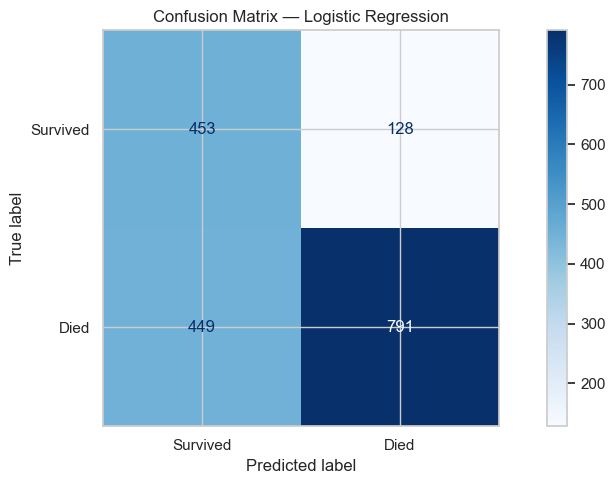

In [18]:
# Confusion matrix — rows = actual, columns = predicted
# Top-left = true negatives (correctly predicted survived)
# Bottom-right = true positives (correctly predicted died)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Died"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
# Add this before plt.show()
plt.savefig("fig3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

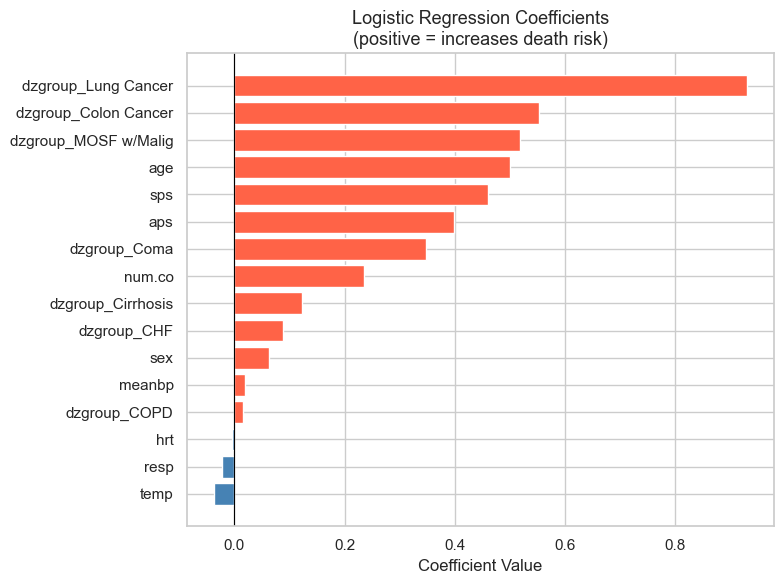

In [19]:
# Feature importance via model coefficients
# Positive coefficient = feature increases probability of death
# Negative coefficient = feature decreases probability of death
coef_df = pd.DataFrame(
    {"feature": X.columns, "coefficient": model.coef_[0]}
).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    "Logistic Regression Coefficients\n(positive = increases death risk)", fontsize=13
)
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("fig4_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

# Mini Project Summary

## Overall
This mini project performed an end-to-end preliminary analysis of the SUPPORT2 dataset — 9,105 critically ill patients across eight disease groups — to predict six-month all-cause mortality using logistic regression. The analysis confirmed that disease group and physiological severity scores are the strongest predictors of death, while establishing the dataset's structure, missingness patterns, and modeling baseline for the full project.

---

## 1. Introduction & Data Loading
**Approach:** Loaded the raw CSV and performed an initial audit of shape, data types, class balance, and missingness.

**Findings:**
- 9,105 patients × 48 variables
- Target variable `death` is imbalanced: 68.1% died (n = 6,201), 31.9% survived (n = 2,904)
- 33 of 48 variables had missing values ranging from 0.3% to 62.0%
- Physician survival estimates (`surv2m`, `surv6m`) excluded as predictors to avoid circularity
- `death` captures all-cause mortality within 6 months; distinct from `hospdead` (in-hospital only)

---

## 2. Data Cleaning & Preparation
**Approach:** Dropped columns with >40% missingness, selected 10 clinically relevant low-missingness features, dropped remaining null rows, binary-encoded `sex`, one-hot encoded `dzgroup` with ARF/MOSF w/Sepsis as reference category.

**Findings:**
- 4 columns dropped for high missingness: `adlp` (62%), `urine` (53.4%), `glucose` (49.4%), `bun` (47.8%)
- Only 2 rows (0.02%) lost to remaining nulls — feature selection was effective
- Final modeling dataset: 9,103 rows × 16 features
- Implausible extreme values noted in `meanbp`, `hrt`, `resp` — deferred to full project
- Albumin (`alb`, 37% missing) identified as clinically important but excluded — priority for imputation in full project

---

## 3. Exploratory Data Analysis
**Approach:** Examined class distribution, death rate by disease group (bar chart), age distribution by outcome (KDE density plot), and Pearson correlations of numeric features with `death`.

**Findings:**
- Class imbalance (68.1%) means accuracy alone is a misleading metric — precision, recall, and F1 required
- Death rates varied substantially across disease groups: Lung Cancer (91.7%) to COPD (58.0%), a 33.7 percentage point spread suggesting disease group is a meaningful predictor
- Age distributions largely overlapped between outcomes; deceased patients peaked slightly older (~70) vs. survivors (~68); crossover at ~age 47
- All individual numeric correlations with `death` were weak (r = -0.031 to 0.179), confirming predictive power lies in feature combinations rather than any single variable
- Strongest numeric correlations: age (r = 0.179), aps (r = 0.157), sps (r = 0.156)

---

## 4. Model Selection
**Approach:** Logistic regression selected for interpretability and appropriateness to binary outcome. 80/20 stratified train/test split. Z-score normalization applied to training data only (test set transformed, not fit). Class imbalance addressed via `class_weight='balanced'`.

**Findings:**
- 80/20 split: 7,282 training / 1,821 test rows; death rate preserved at 68.1% in both partitions
- Balanced class weighting chosen over SMOTE for simplicity; penalizes minority class misclassification proportionally
- Scaling mean confirmed at ~0.0 — no data leakage
- Single train/test split is a known limitation; cross-validation recommended for full project

---

## 5. Model Analysis
**Approach:** Evaluated model on held-out test set using accuracy, precision, recall, F1-score, confusion matrix, and standardized logistic regression coefficients.

**Findings:**
- Overall accuracy: 68.3% — marginally above the 68.1% naive baseline
- Deceased class: precision 0.86, recall 0.64, F1 0.73 — high confidence predictions but misses 36% of deaths
- Survivor class: precision 0.50, recall 0.78, F1 0.61 — catches most survivors but high false positive rate
- Confusion matrix: 453 true negatives, 791 true positives, 128 false positives, 449 false negatives
- 449 false negatives (missed deaths) are the primary clinical concern — direct tradeoff of balanced class weighting
- Strongest predictors: `dzgroup_Lung Cancer` (largest coefficient by substantial margin), `dzgroup_Colon Cancer`, `dzgroup_MOSF w/Malig`, `age`, `sps`, `aps`
- `resp` and `temp` showed small negative coefficients — lower values associated with increased mortality risk
- Threshold optimization via ROC curve analysis recommended for full project

---

## Limitations & Full Project Recommendations
| Limitation | Recommendation |
|---|---|
| Row-wise deletion of missing values | Median or KNN imputation to recover `alb` and other informative variables |
| Single train/test split | K-fold cross-validation for stable performance estimates |
| One model tested | Compare Decision Tree, Random Forest (Chapter 8) |
| Default 0.5 classification threshold | ROC curve analysis on dedicated validation set |
| Outliers retained in physiological variables | Formal outlier detection and treatment |
| No formal hypothesis testing | Chi-square test on disease group mortality differences (Chapter 5) |
| Class imbalance addressed only via weighting | Evaluate SMOTE as alternative |
